In [911]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [912]:
df = pd.read_csv("../data/hdi_data.csv")

In [913]:
df.head()

,Country,Life_Expectancy,Expected_Schooling,Mean_Schooling,GNI_per_Capita,HDI
0,Norway,83.2,18.2,13.0,68000,0.961
1,Switzerland,84.0,16.5,13.9,70000,0.962
2,Germany,81.2,17.1,14.2,56000,0.950
3,United States,77.5,16.3,13.7,76000,0.921
4,Canada,82.3,16.4,13.8,58000,0.936


In [914]:
df.shape

(20, 6)

In [915]:
df.columns

Index(['Country', 'Life_Expectancy', 'Expected_Schooling', 'Mean_Schooling',
       'GNI_per_Capita', 'HDI'],
      dtype='object')

In [916]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             20 non-null     object 
 1   Life_Expectancy     20 non-null     float64
 2   Expected_Schooling  20 non-null     float64
 3   Mean_Schooling      20 non-null     float64
 4   GNI_per_Capita      20 non-null     int64  
 5   HDI                 20 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 1.1+ KB


In [917]:
df.describe()

,Life_Expectancy,Expected_Schooling,Mean_Schooling,GNI_per_Capita,HDI
count,20.000000,20.000000,20.000000,20.000000,20.000000
mean,75.860000,14.895000,10.545000,35562.550000,0.804000
std,8.476183,2.964079,3.186728,28764.055741,0.156001
min,54.700000,8.700000,5.100000,4200.000000,0.544000
25%,69.150000,12.825000,7.700000,6838.250000,0.663500
50%,77.850000,15.450000,11.650000,30800.000000,0.854500
75%,83.050000,16.675000,13.400000,59000.000000,0.942250
max,84.800000,21.100000,14.200000,88000.000000,0.962000


In [918]:
df.isnull().sum()

Country               0
Life_Expectancy       0
Expected_Schooling    0
Mean_Schooling        0
GNI_per_Capita        0
HDI                   0
dtype: int64

In [919]:
df.isnull().sum()

Country               0
Life_Expectancy       0
Expected_Schooling    0
Mean_Schooling        0
GNI_per_Capita        0
HDI                   0
dtype: int64

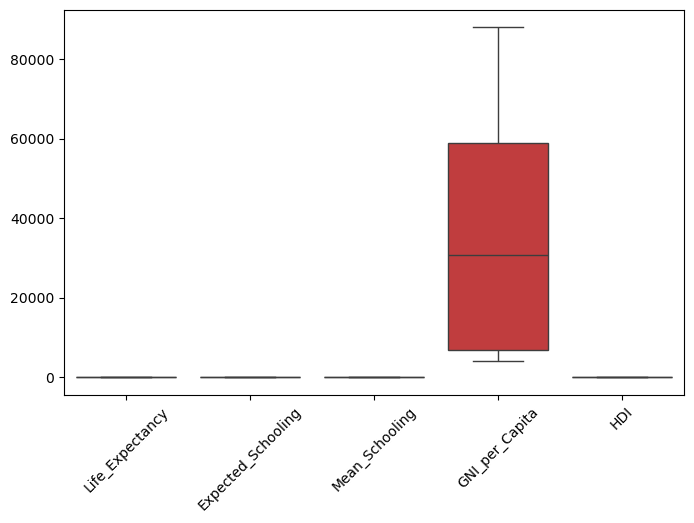

In [920]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Life_Expectancy','Expected_Schooling',
                     'Mean_Schooling','GNI_per_Capita','HDI']])
plt.xticks(rotation=45)
plt.show()

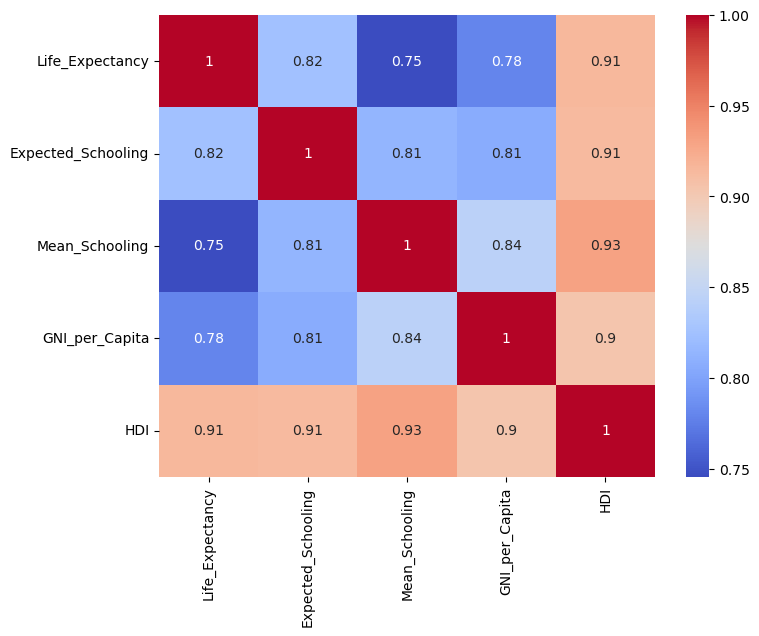

In [921]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

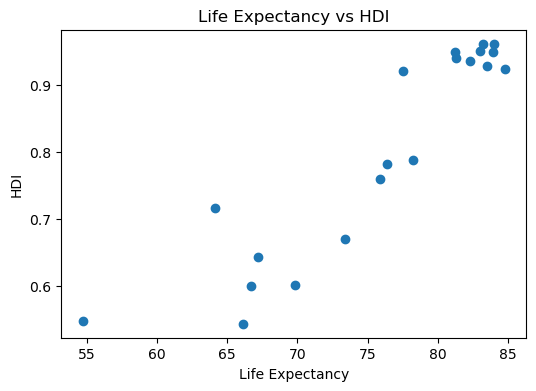

In [922]:
plt.figure(figsize=(6,4))
plt.scatter(df['Life_Expectancy'], df['HDI'])
plt.xlabel("Life Expectancy")
plt.ylabel("HDI")
plt.title("Life Expectancy vs HDI")
plt.show()

In [923]:
df.duplicated().sum()

0

In [924]:
df.drop_duplicates(inplace=True)

In [925]:
df.isnull().sum()

Country               0
Life_Expectancy       0
Expected_Schooling    0
Mean_Schooling        0
GNI_per_Capita        0
HDI                   0
dtype: int64

In [926]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [927]:
df["Education_Index"] = (
    df["Expected_Schooling"] + df["Mean_Schooling"]
) / 2

In [928]:
import numpy as np

df["Log_GNI"] = np.log(df["GNI_per_Capita"])

In [929]:
df.head()

,Country,Life_Expectancy,Expected_Schooling,Mean_Schooling,GNI_per_Capita,HDI,Education_Index,Log_GNI
0,Norway,83.2,18.2,13.0,68000,0.961,15.60,11.127263
1,Switzerland,84.0,16.5,13.9,70000,0.962,15.20,11.156251
2,Germany,81.2,17.1,14.2,56000,0.950,15.65,10.933107
3,United States,77.5,16.3,13.7,76000,0.921,15.00,11.238489
4,Canada,82.3,16.4,13.8,58000,0.936,15.10,10.968198


In [930]:
df["Education_Index"] = (
    df["Expected_Schooling"] + df["Mean_Schooling"]
) / 2

In [931]:
import numpy as np

df["Log_GNI"] = np.log(df["GNI_per_Capita"])

In [932]:
df.head()

,Country,Life_Expectancy,Expected_Schooling,Mean_Schooling,GNI_per_Capita,HDI,Education_Index,Log_GNI
0,Norway,83.2,18.2,13.0,68000,0.961,15.60,11.127263
1,Switzerland,84.0,16.5,13.9,70000,0.962,15.20,11.156251
2,Germany,81.2,17.1,14.2,56000,0.950,15.65,10.933107
3,United States,77.5,16.3,13.7,76000,0.921,15.00,11.238489
4,Canada,82.3,16.4,13.8,58000,0.936,15.10,10.968198


In [933]:
X = df[
    [
        "Life_Expectancy",
        "Expected_Schooling",
        "Mean_Schooling",
        "Log_GNI",
        "Education_Index"
    ]
]

y = df["HDI"]

In [934]:
X.head()

,Life_Expectancy,Expected_Schooling,Mean_Schooling,Log_GNI,Education_Index
0,83.2,18.2,13.0,11.127263,15.60
1,84.0,16.5,13.9,11.156251,15.20
2,81.2,17.1,14.2,10.933107,15.65
3,77.5,16.3,13.7,11.238489,15.00
4,82.3,16.4,13.8,10.968198,15.10


In [935]:
y.head()

0    0.961
1    0.962
2    0.950
3    0.921
4    0.936
Name: HDI, dtype: float64

In [936]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [937]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16, 5)
(4, 5)
(16,)
(4,)


In [938]:
from sklearn.linear_model import LinearRegression

In [939]:
model = LinearRegression()

In [940]:
model.fit(X_train, y_train)

LinearRegression()

In [941]:
predictions = model.predict(X_test)

In [942]:
print(predictions)

[0.95509428 0.67226004 0.62271401 0.96174948]


In [943]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [944]:
mae = mean_absolute_error(y_test, predictions)
print("MAE:", mae)

MAE: 0.007532570842533809


In [945]:
mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)

MSE: 0.00012788651888138013


In [946]:
r2 = r2_score(y_test, predictions)
print("R2 Score:", r2)

R2 Score: 0.9952921019766281


In [947]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [948]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [949]:
import joblib

In [950]:
joblib.dump(rf, "../models/hdi_model.pkl")

['../models/hdi_model.pkl']